In [44]:
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sqlite3

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Conv1D,
MaxPooling1D,Flatten,Input,Dropout)
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (accuracy_score
,classification_report,
confusion_matrix,
precision_score,
recall_score,
f1_score,
roc_auc_score)

from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [43]:
# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/dhrubangtalukdar/store-item-demand-forecasting-dataset


In [4]:
# Show all files inside the folder
print("\nFiles in dataset folder:")
print(os.listdir(path))


Files in dataset folder:
['retail_sales.csv']


In [5]:
# Load the CSV file
csv_file = os.path.join(path, 'retail_sales.csv')

# Read dataset into pandas dataframe
df = pd.read_csv(csv_file)
df.head(11)

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1
5,2019-01-06,store_1,item_1,38,21.30,0,6,1
6,2019-01-07,store_1,item_1,45,21.30,0,0,1
7,2019-01-08,store_1,item_1,48,21.30,0,1,1
8,2019-01-09,store_1,item_1,50,21.30,0,2,1
9,2019-01-10,store_1,item_1,44,21.30,0,3,1


In [6]:
# Print dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [7]:
# Print dataset structure
print("\nDataset structure:")
df.describe()


Dataset structure:


,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [8]:
# SQL- style ingestion 
conn = sqlite3.connect("retail_sales.db")

# Store dataframe into SQL table
df.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False)

print('Dataset stored successfully')

Dataset stored successfully


In [9]:
# SQL Querying 
query = """
SELECT store_id AS store,
       item_id AS item,
       AVG(sales) AS avg_sales
FROM sales_data
GROUP BY store_id, item_id
"""
# Execute query
sales_summary = pd.read_sql(query, conn)

# Print result
print(sales_summary.head())

     store     item  avg_sales
0  store_1   item_1  44.780942
1  store_1  item_10  22.625958
2  store_1  item_11  24.568456
3  store_1  item_12  20.680175
4  store_1  item_13  39.995619


# 4. DATA PRE-PROCESSING

In [10]:
# 4.1 Missing Values
print(df.isnull().sum())

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64


In [11]:
## 4.2 Duplicate Records 
print(df.duplicated().sum())

0


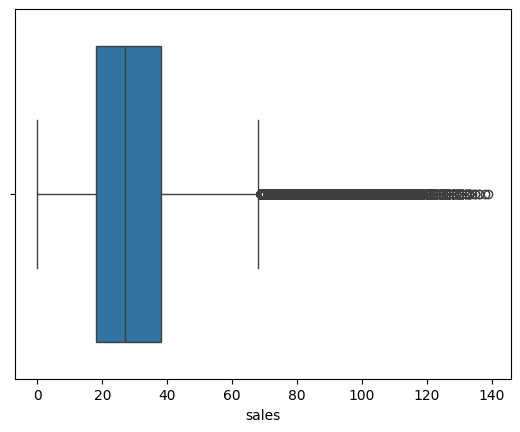

In [12]:
# 4.3 Outlier Detection 
sns.boxplot(x=df['sales'])

plt.show()

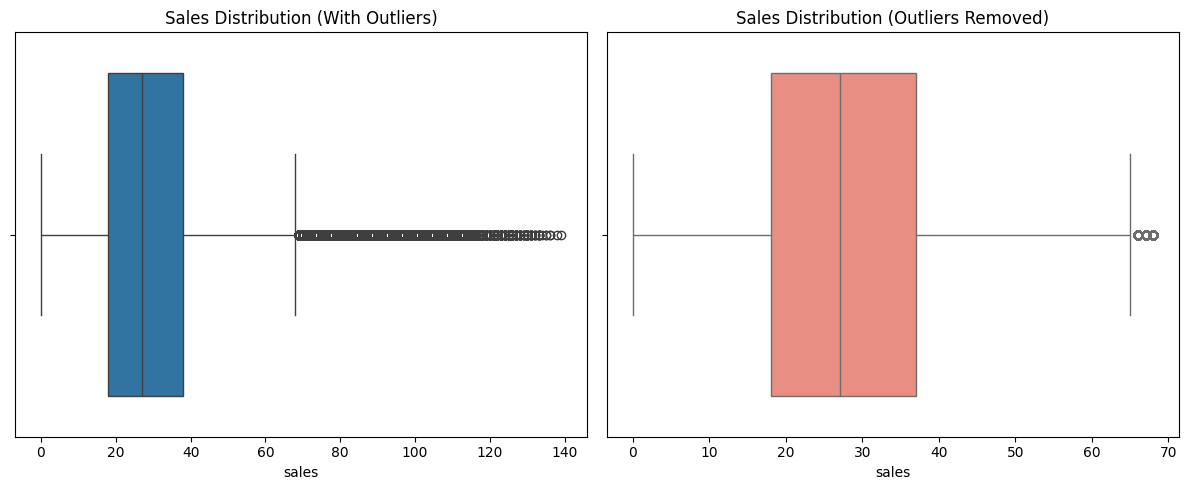

In [13]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
    ~((df['sales'] < (Q1 - 1.5 * IQR)) |
      (df['sales'] > (Q3 + 1.5 * IQR)))].copy()

# 2. Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Before
sns.boxplot(x=df['sales'], ax=axes[0])
axes[0].set_title('Sales Distribution (With Outliers)')

# Plot After
sns.boxplot(data=df_clean, x='sales', ax=axes[1], color='salmon')
axes[1].set_title('Sales Distribution (Outliers Removed)')

plt.tight_layout()
plt.show()

#### 4.4 Feature Engineering

In [14]:
df_clean.ffill(inplace=True)

In [15]:
# Convert date column
df_clean['date'] = pd.to_datetime(df_clean['date'])

In [16]:
# Creating time-based features

df_clean['month'] = df_clean['date'].dt.month

df_clean['day_of_week'] = df_clean['date'].dt.dayofweek

df_clean['year'] = df_clean['date'].dt.year

In [17]:
# creating historical sales features
df_clean['lag_7'] = df_clean.groupby(["store_id","item_id"])['sales'].shift(7)

df_clean['lag_30'] = df_clean.groupby(["store_id","item_id"])['sales'].shift(30)

# Rolling mean

df_clean['rolling_mean_7'] = (df_clean.groupby(["store_id","item_id"])['sales']
                              .rolling(window=7)
                              .mean()
                              .reset_index(level=[0, 1], drop= True))
                              

df_clean['rolling_mean_30'] = (df_clean.groupby(["store_id","item_id"])['sales']
                               .rolling(window=30)
                               .mean()
                               .reset_index(level=[0, 1], drop= True))

In [18]:
# Remove NaN values created by LAGS
df_clean.dropna(inplace=True)

In [19]:
# Create Demand Classes

def classify_demand(x):

    if x < 30:
        return 0

    elif x < 60:
        return 1

    else:
        return 2

df_clean['demand_class'] = (df_clean['sales']
                           .apply(classify_demand))


In [20]:
# Select Features
features = [
    'store_id',
    'item_id',
    'month',
    'day_of_week',
    'lag_7',
    'rolling_mean_7',
    'rolling_mean_30']

X = df_clean[features]

y = df_clean['demand_class']

print(X.head(11))

   store_id item_id  month  day_of_week  lag_7  rolling_mean_7  \
30  store_1  item_1      1            3   40.0       44.142857   
31  store_1  item_1      2            4   38.0       44.571429   
32  store_1  item_1      2            5   34.0       44.571429   
33  store_1  item_1      2            6   40.0       43.714286   
34  store_1  item_1      2            0   44.0       46.571429   
35  store_1  item_1      2            1   46.0       47.714286   
36  store_1  item_1      2            2   57.0       47.857143   
37  store_1  item_1      2            3   50.0       48.285714   
38  store_1  item_1      2            4   41.0       48.000000   
39  store_1  item_1      2            5   34.0       50.285714   
40  store_1  item_1      2            6   34.0       53.571429   

    rolling_mean_30  
30        43.066667  
31        42.666667  
32        42.500000  
33        42.466667  
34        42.900000  
35        43.433333  
36        43.866667  
37        44.033333  
38       

In [21]:
#Convert categorical text columns into 0s and 1s
X_encoded = pd.get_dummies(df_clean.drop(columns=['sales', 'date']), columns=['store_id', 'item_id'])

In [22]:
# Scale feature
scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X_encoded)

### 4.6  EXPLORATORY DATA ANALYSIS (EDA)

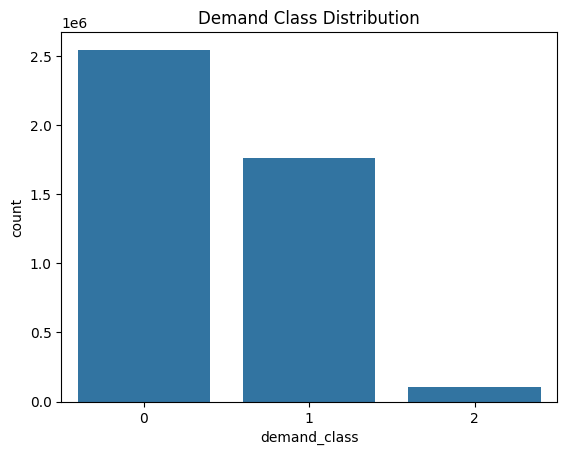

In [23]:
# Checking Class Distribution 
sns.countplot(
    x='demand_class',
    data=df_clean)

plt.title("Demand Class Distribution")

plt.show()

<Figure size 1000x500 with 0 Axes>

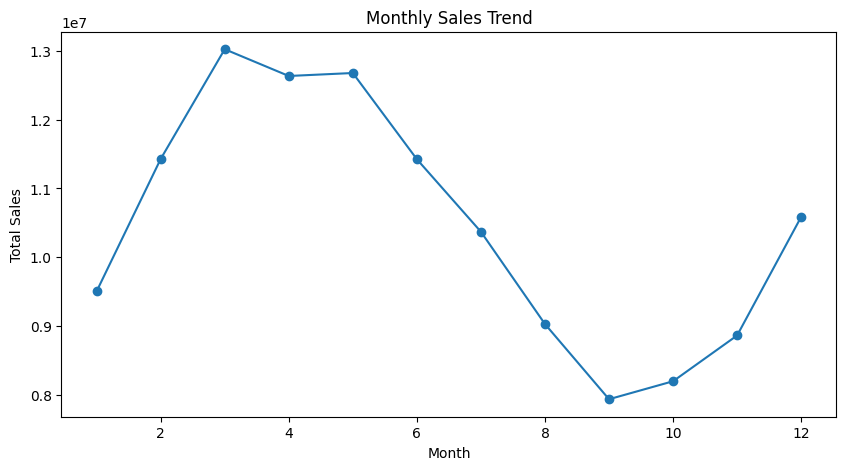

In [24]:
# Analyse monthly sales trend

plt.figure(figsize=(10,5))

# Monthly trend

monthly_sales = (
    df_clean.groupby('month')['sales']
    .sum()
    .reset_index())

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['month'],
    monthly_sales['sales'],
    marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

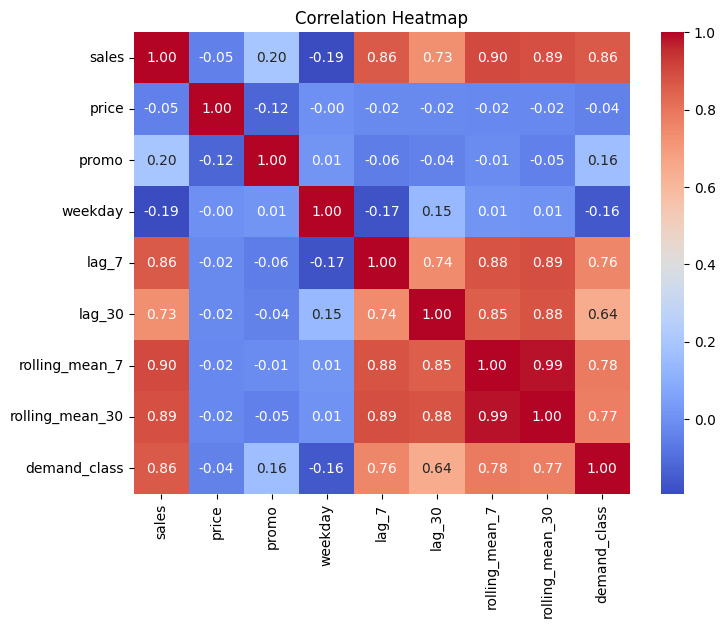

In [25]:
#Analysing Correlation Heatmap

# Select numerical columns
numeric_df = df_clean.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

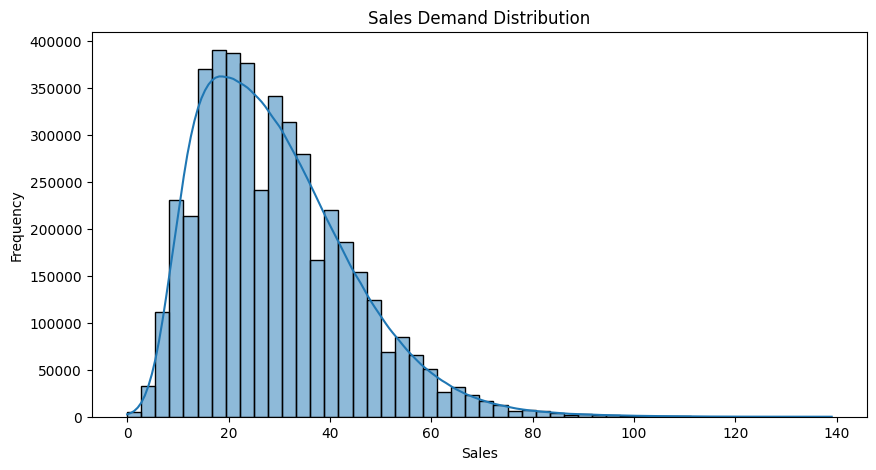

In [26]:
#Demand Distribution Plot

plt.figure(figsize=(10,5))

sns.histplot(
    df['sales'],
    bins=50,
    kde=True)

plt.title("Sales Demand Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

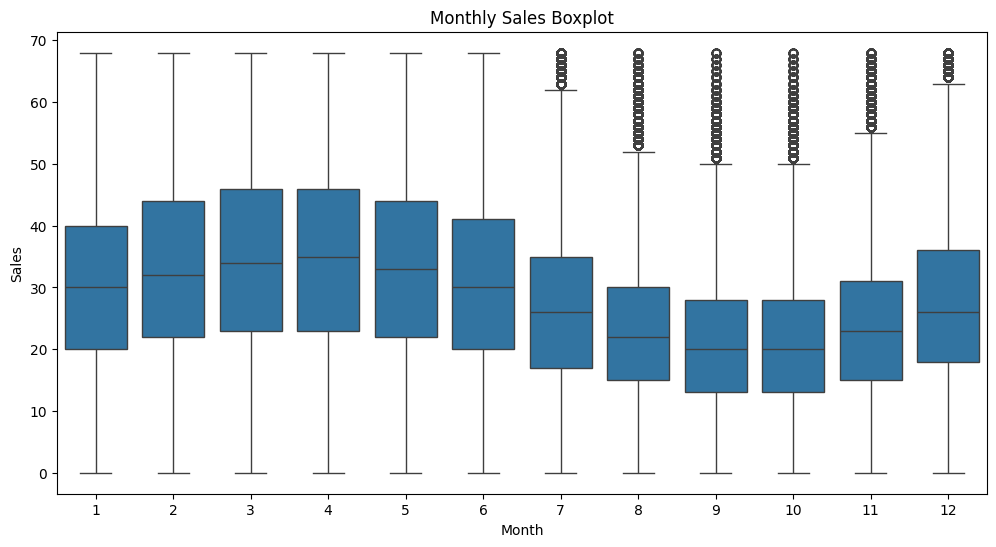

In [27]:
# Boxplot

plt.figure(figsize=(12,6))

sns.boxplot(
    x='month',
    y='sales',
    data=df_clean)

plt.title("Monthly Sales Boxplot")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

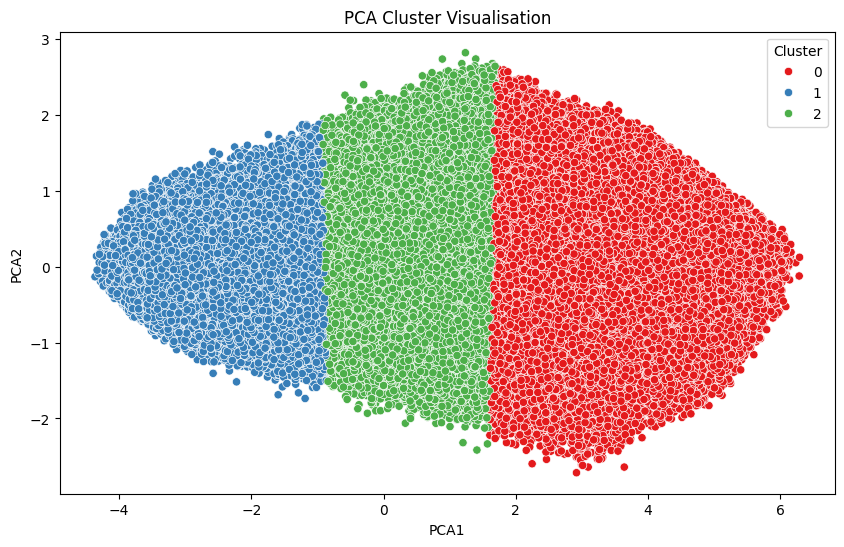

In [34]:
# PCA Cluster Visualisation 
pca_features = df_clean[[
    'sales',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30']]

# Standardise data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(pca_features)

# PCA transformation
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42)

clusters = kmeans.fit_predict(pca_components)

# Create PCA dataframe
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1','PCA2'])

pca_df['Cluster'] = clusters

# Plot PCA clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1')

plt.title("PCA Cluster Visualisation")

plt.show()

#### 4.7 FEATURE SCALING + TRAIN TEST SPLIT

#### Chronological Train Test Split

In [29]:
# Prevent data leakage
# Calculate the split point index  (80% train, 20% test)

df_clean = df_clean.sort_values("date")

split = int(len(df_clean)*0.80)

train = df_clean.iloc[:split]

test = df_clean.iloc[split:]

features = [
'price',
'promo',
'month',
'day_of_week',
'lag_7',
'lag_30',
'rolling_mean_7',
'rolling_mean_30']

X_train = train[features]
X_test = test[features]

y_train = train["demand_class"]
y_test = test["demand_class"]

In [30]:
# Pipeline & Scaling

numerical_features = [
'price',
'lag_7',
'lag_30',
'rolling_mean_7',
'rolling_mean_30']

categorical_features = [
'promo',
'month',
'day_of_week']

preprocessor = ColumnTransformer(
transformers=[
('num',
StandardScaler(),
numerical_features),
('cat',
'passthrough',
categorical_features)])

X_train_scaled = preprocessor.fit_transform(X_train)

X_test_scaled = preprocessor.transform(X_test)

# 5. Implementation and Evaluation

#### 5.1 Multilayer Perceptron (MLP)

In [54]:
# ANN 
mlp = Sequential()

mlp.add(Dense(15,activation="relu",
input_shape=(X_train_scaled.shape[1],)))

mlp.add(Dense(25, activation="relu"))
mlp.add(Dense(25, activation="relu"))
mlp.add(Dense(20, activation="relu"))

mlp.add(Dense(3, activation="softmax"))

mlp.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

history = mlp.fit(
X_train_scaled,
y_train,
epochs=50,
batch_size=32,
validation_split=0.20)

loss, acc = mlp.evaluate(
X_test_scaled,
y_test)

print("MLP Accuracy:", acc)

Epoch 1/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 248s 3ms/step - accuracy: 0.9270 - loss: 0.1662 - val_accuracy: 0.9242 - val_loss: 0.1727
Epoch 2/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 246s 3ms/step - accuracy: 0.9296 - loss: 0.1595 - val_accuracy: 0.9255 - val_loss: 0.1677
Epoch 3/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 245s 3ms/step - accuracy: 0.9301 - loss: 0.1587 - val_accuracy: 0.9262 - val_loss: 0.1704
Epoch 4/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 243s 3ms/step - accuracy: 0.9303 - loss: 0.1582 - val_accuracy: 0.9257 - val_loss: 0.1701
Epoch 6/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 244s 3ms/step - accuracy: 0.9302 - loss: 0.1581 - val_accuracy: 0.9259 - val_loss: 0.1693
Epoch 7/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 244s 3ms/step - accuracy: 0.9304 - loss: 0.1581 - val_accuracy: 0.9257 - val_loss: 0.1677
Epoch 8/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 245s 3ms/step - accuracy: 0.9303 - loss: 0.1581 - val_accuracy: 0.9257 - val_loss: 0.1686
Epoch 9/50
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 243s 3ms/step - ac

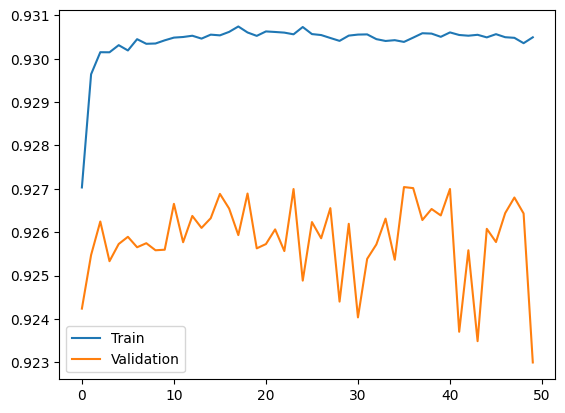

In [55]:
# MLP Evaluation 
# Accuracy Curve
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(
["Train","Validation"])

plt.show()

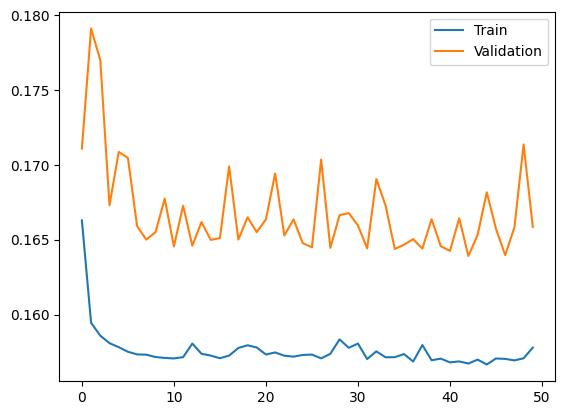

In [46]:
# Loss Curve
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(
["Train","Validation"])

plt.show()

In [56]:
y_pred_prob = mlp.predict(X_test_scaled)

y_pred = np.argmax(
    y_pred_prob,
    axis=1)

27599/27599 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step


In [78]:
print(
    classification_report(
        y_test,
        y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94    449402
           1       0.92      0.90      0.91    400689
           2       0.87      0.64      0.74     33062

    accuracy                           0.92    883153
   macro avg       0.91      0.83      0.86    883153
weighted avg       0.92      0.92      0.92    883153



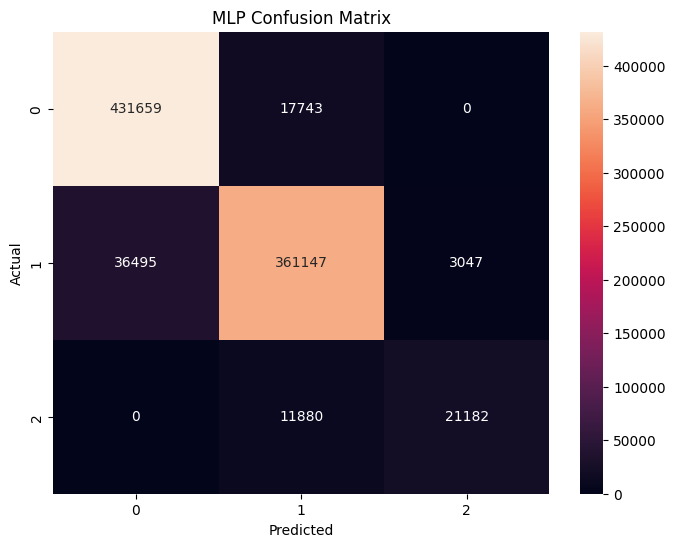

In [58]:
cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d")

plt.title("MLP Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
loss, accuracy = mlp.evaluate(
    X_train_scaled
         ,y_train,
    verbose=0)

print(f"MLP Test Accuracy: {accuracy:.4f}")

MLP Test Accuracy: 0.9272


In [85]:
mlp_precision = precision_score(
    y_test,
    y_pred,
    average="weighted")

mlp_recall = recall_score(
    y_test,
    y_pred,
    average="weighted")

mlp_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall   : {mlp_recall:.4f}")
print(f"F1 Score : {mlp_f1:.4f}")

Accuracy : 0.9272
Precision: 0.9212
Recall   : 0.9217
F1 Score : 0.9205


#### 5.2 Ensemble Model

##### 5.2.1 LightGBM Model 

In [32]:
# lgbm Model
lgbm = lgb.LGBMClassifier(n_estimators=300
                          ,learning_rate=0.05
                          ,num_leaves=31
                          ,random_state=42)

lgbm.fit(X_train_scaled
         ,y_train)

pred_lgb = lgbm.predict(X_test_scaled)

print(classification_report(y_test,pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 3532611, number of used features: 8
[LightGBM] [Info] Start training from score -0.521318
[LightGBM] [Info] Start training from score -0.952716
[LightGBM] [Info] Start training from score -3.883891
              precision    recall  f1-score   support

           0       0.94      0.94      0.94    449402
           1       0.92      0.92      0.92    400689
           2       0.81      0.76      0.79     33062

    accuracy                           0.93    883153
   macro avg       0.89      0.88      0.88    883153
weighted avg       0.93      0.93      0.93    883153



In [66]:
lgb_acc = accuracy_score(
    y_test,
    pred_lgb)

print(f"LightGBM Accuracy: {lgb_acc:.2f}")

LightGBM Accuracy: 0.93


In [71]:
lgb_precision = precision_score(
    y_test,
    pred_lgb,
    average="weighted")

lgb_recall = recall_score(
    y_test,
    pred_lgb,
    average="weighted")

lgb_f1 = f1_score(
    y_test,
    pred_lgb,
    average="weighted")

print(f"Accuracy : {lgb_acc:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall   : {lgb_recall:.4f}")
print(f"F1 Score : {lgb_f1:.4f}")

Accuracy : 0.9259
Precision: 0.9257
Recall   : 0.9259
F1 Score : 0.9258


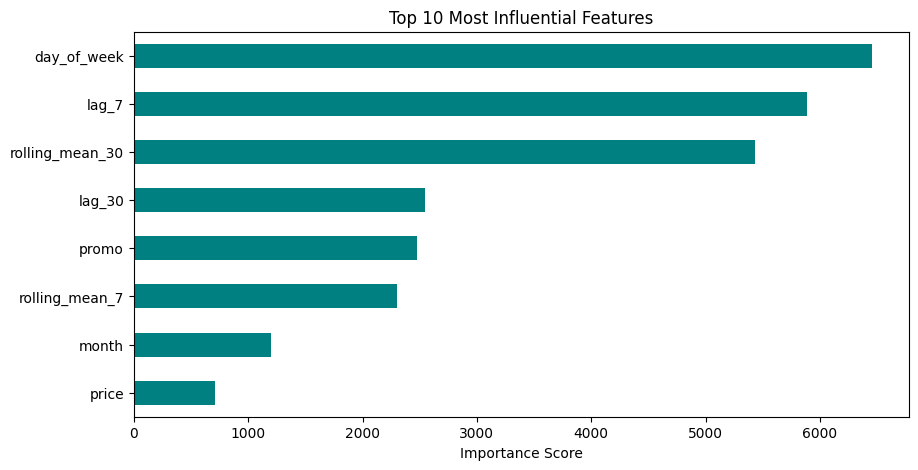

In [53]:
# Ploting feature Importance 
# A quick chart to show which features are most influential

importances = pd.Series(lgbm.feature_importances_, index=features)
top_features = importances.nlargest(10)                             # the top 10 features

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='teal')
plt.title('Top 10 Most Influential Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()                               # Putting the most important feature at the top
plt.show()

#### XGBoost model

In [89]:
xgb = XGBClassifier(
n_estimators=200,
max_depth=6,
learning_rate=0.05,
random_state=42)

xgb.fit(
X_train_scaled,
y_train)

pred_xgb = xgb.predict(
X_test_scaled)

print(
classification_report(
y_test,
pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    449402
           1       0.92      0.92      0.92    400689
           2       0.82      0.75      0.78     33062

    accuracy                           0.93    883153
   macro avg       0.89      0.87      0.88    883153
weighted avg       0.93      0.93      0.93    883153



In [90]:
xgb_precision = precision_score(
    y_test,
    pred_xgb,
    average="weighted")

xgb_recall = recall_score(
    y_test,
    pred_xgb,
    average="weighted")

xgb_f1 = f1_score(
    y_test,
    pred_xgb,
    average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall   : {mlp_recall:.4f}")
print(f"F1 Score : {mlp_f1:.4f}")

Accuracy : 0.9272
Precision: 0.9212
Recall   : 0.9217
F1 Score : 0.9205


# Deep Convolutional Neural Network (CNN)

In [35]:
def prepare_cnn_data(X_train, X_test):

    X_train_cnn = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],1)

    X_test_cnn = X_test.reshape(
        X_test.shape[0],
        X_test.shape[1],1)

    return X_train_cnn, X_test_cnn


# Apply transformation
X_train_cnn, X_test_cnn = prepare_cnn_data(
    X_train_scaled,
    X_test_scaled)

print("CNN Training Shape:", X_train_cnn.shape)
print("CNN Testing Shape :", X_test_cnn.shape)

CNN Training Shape: (3532611, 8, 1)
CNN Testing Shape : (883153, 8, 1)


In [36]:
def build_cnn_model(
    input_shape,
    num_classes):

    model = Sequential([Input(shape=input_shape),
                        Conv1D(filters=32
                               ,kernel_size=3
                               ,activation="relu"
                               ,padding="same"),
                        MaxPooling1D(pool_size=2)
                        ,Conv1D(filters=64
                                ,kernel_size=3
                                ,activation="relu"
                                ,padding="same")
                        ,MaxPooling1D(pool_size=2)
                        ,Flatten()
                        ,Dense(64,activation="relu")
                        ,Dropout(0.30),Dense(num_classes
                                             ,activation="softmax")])
    model.compile(optimizer="adam"
                  ,loss="sparse_categorical_crossentropy"
                  ,metrics=["accuracy"])

    return model

In [37]:
# Authomatic Class Detection

num_classes = len(np.unique(y_train))

print("Total Classes:", num_classes)

Total Classes: 3


In [45]:
# Build CNN

cnn_model = build_cnn_model(

    input_shape=(
        X_train_cnn.shape[1],
        X_train_cnn.shape[2])
    ,num_classes=num_classes)

cnn_model.summary()

I0000 00:00:1780311332.880392      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780311332.886480      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 4, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,787 (57.76 KB)

 Trainable params: 14,787 (57.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CNN

early_stop = EarlyStopping(monitor="val_loss"
                           ,patience=5
                           ,restore_best_weights=True)

cnn_history = cnn_model.fit(X_train_cnn
                            ,y_train
                            ,validation_split=0.20
                            ,epochs=30
                            ,batch_size=32
                            ,callbacks=[early_stop]
                            ,verbose=1)

Epoch 1/30


I0000 00:00:1780311824.445696     116 service.cc:152] XLA service 0x7ce0000024c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780311824.445753     116 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780311824.445761     116 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780311824.842668     116 cuda_dnn.cc:529] Loaded cuDNN version 91002


   61/88316 ━━━━━━━━━━━━━━━━━━━━ 3:49 3ms/step - accuracy: 0.7628 - loss: 0.6242

I0000 00:00:1780311827.469283     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88316/88316 ━━━━━━━━━━━━━━━━━━━━ 264s 3ms/step - accuracy: 0.9265 - loss: 0.1694 - val_accuracy: 0.9231 - val_loss: 0.1738
Epoch 2/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 257s 3ms/step - accuracy: 0.9293 - loss: 0.1624 - val_accuracy: 0.9254 - val_loss: 0.1676
Epoch 3/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 256s 3ms/step - accuracy: 0.9299 - loss: 0.1613 - val_accuracy: 0.9252 - val_loss: 0.1696
Epoch 5/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 266s 3ms/step - accuracy: 0.9298 - loss: 0.1609 - val_accuracy: 0.9248 - val_loss: 0.1697
Epoch 6/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 256s 3ms/step - accuracy: 0.9299 - loss: 0.1608 - val_accuracy: 0.9260 - val_loss: 0.1671
Epoch 7/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 255s 3ms/step - accuracy: 0.9303 - loss: 0.1595 - val_accuracy: 0.9268 - val_loss: 0.1656
Epoch 11/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 257s 3ms/step - accuracy: 0.9303 - loss: 0.1593 - val_accuracy: 0.9266 - val_loss: 0.1669
Epoch 13/30
88316/88316 ━━━━━━━━━━━━━━━━━━━━ 263s 3ms/step - accuracy: 0

In [47]:
# Evaluate CNN

cnn_loss, cnn_accuracy = cnn_model.evaluate(

    X_test_cnn,

    y_test,

    verbose=0)

print(f"CNN Accuracy: {cnn_accuracy:.4f}")

CNN Accuracy: 0.9249


In [48]:
#
cnn_probs = cnn_model.predict(X_test_cnn)

cnn_predictions = np.argmax(
    cnn_probs,
    axis=1)

27599/27599 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step


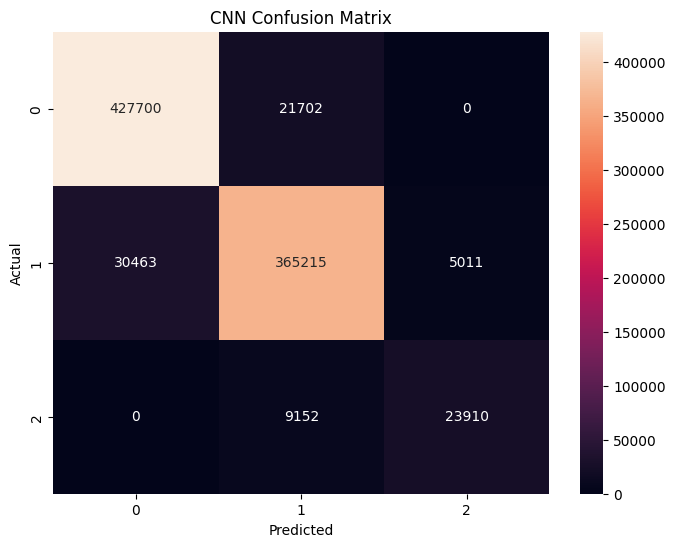

In [49]:
cm = confusion_matrix(
    y_test,
    cnn_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

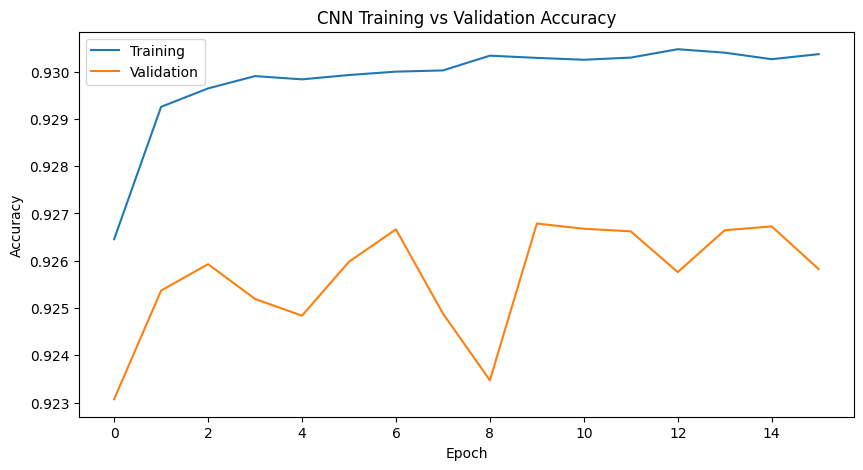

In [50]:
plt.figure(figsize=(10,5))

plt.plot(
    cnn_history.history["accuracy"]
)

plt.plot(
    cnn_history.history["val_accuracy"]
)

plt.title(
    "CNN Training vs Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

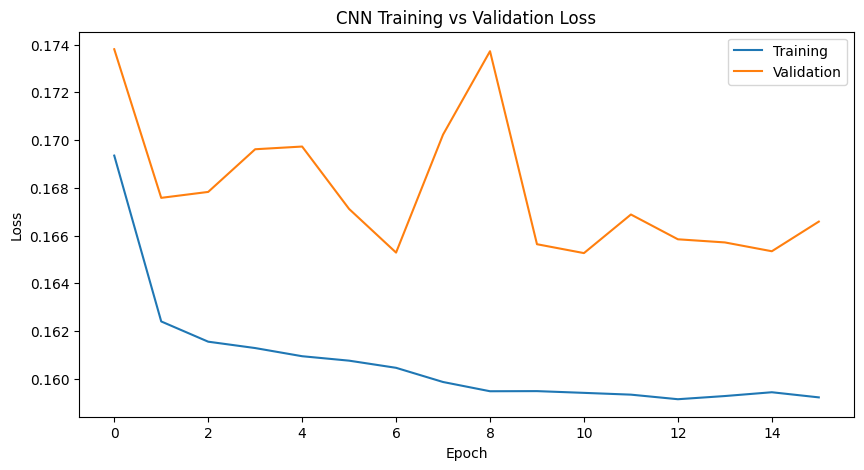

In [51]:
plt.figure(figsize=(10,5))

plt.plot(
    cnn_history.history["loss"]
)

plt.plot(
    cnn_history.history["val_loss"]
)

plt.title(
    "CNN Training vs Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"])

plt.show()

      Model  Accuracy
0       MLP  0.921684
1   XGBoost  0.927199
2  LightGBM  0.925923
3       CNN  0.924896


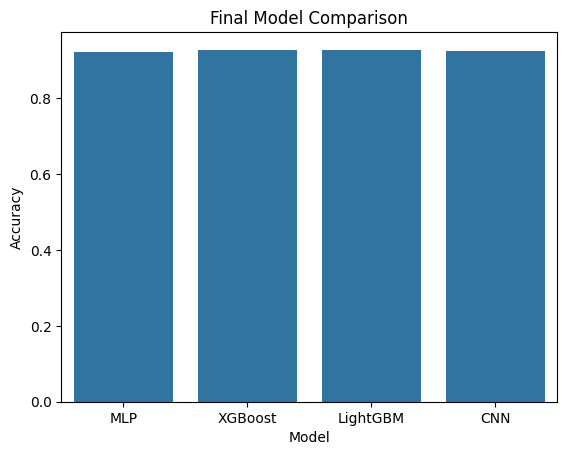

In [68]:
results = pd.DataFrame({

"Model":[
    "MLP",
    "XGBoost",
    "LightGBM",
    "CNN"],

"Accuracy":[
    acc,
    accuracy,
    lgb_acc,
    cnn_accuracy]})

print(results)

sns.barplot(data=results,
x="Model",
y="Accuracy")

plt.title(
"Final Model Comparison")

plt.show()

In [95]:
cnn_precision = precision_score(
    y_test,
    cnn_predictions,
    average="weighted")

cnn_recall = recall_score(
    y_test,
    cnn_predictions,
    average="weighted")

cnn_f1 = f1_score(
    y_test,
    cnn_predictions,
    average="weighted")

print(f"Accuracy : {lgb_acc:.4f}")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall   : {lgb_recall:.4f}")
print(f"F1 Score : {lgb_f1:.4f}")

Accuracy : 0.9259
Precision: 0.9257
Recall   : 0.9259
F1 Score : 0.9258


In [94]:
comparison = pd.DataFrame({

    "Model":[
        "MLP",
        "CNN",
        "XGBoost",
        "LightGBM"],

    "Accuracy":[
        acc,
    accuracy,
    lgb_acc,
    cnn_accuracy],

    "Precision":[
        mlp_precision,
        cnn_precision,
        xgb_precision,
        lgb_precision
    ],

    "Recall":[
        mlp_recall,
        cnn_recall,
        xgb_recall,
        lgb_recall],

    "F1 Score":[
        mlp_f1,
        cnn_f1,
        xgb_f1,
        lgb_f1]})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,MLP,0.921684,0.921230,0.921684,0.920518
1,CNN,0.927199,0.924336,0.924896,0.924428
2,XGBoost,0.925923,0.925138,0.925441,0.925238
3,LightGBM,0.924896,0.925696,0.925923,0.925783
